#NYC Resiliency Exposure Forecast for Coastal Flooding
##How does the protection of at-risk buildings vary across NYC neighborhoods and coastal flooding scenarios?

[NYC Climate Budgeting Report: Resiliency Exposure Forecast - Coastal Flooding dataset](https://data.cityofnewyork.us/Environment/NYC-Climate-Budgeting-Report-Resiliency-Exposure-F/7n9x-tbtd/about_data) from NYC OMB using latest update 04/21/26 in CSV format, aggregated at the Neigborhood Tabulation Area(NTA) level, and intended to evaluate how planned coastal protection measures may reduce future flood exposure.

Additional dataset information, please visit:

*   [NYC Office of Management and Budget (OMB) FY2026 Climate Budgeting Report Technical Appendix](https://www.nyc.gov/assets/omb/downloads/pdf/exec25/exec25-nyccbta.pdf)
*   [NYC OpenData Dataset Data Dictionary](https://https://data.cityofnewyork.us/api/views/7n9x-tbtd/files/d190fb4b-f078-4558-a2ec-a36037fe03e8?download=true&filename=Resiliency_Coastal_Flood_Forecast_Data_Dictonary%20(to%20OTI%20@073125.xlsx)

##Importing data

In [1]:
URL = "https://data.cityofnewyork.us/api/views/7n9x-tbtd/rows.csv?$limit=3000"

In [2]:
import pandas as pd
df = pd.read_csv(URL)

##Analysis of data quality

In [3]:
df.shape

(2620, 8)

In [4]:
df.columns

Index(['PUBLICATION_DATE', 'NTA_Code', 'NTA_Name', 'NTAAbbrev',
       'Scenario_Code', 'Scenario_Name', 'Count', 'Percent'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2620 entries, 0 to 2619
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PUBLICATION_DATE  2620 non-null   object 
 1   NTA_Code          2620 non-null   object 
 2   NTA_Name          2620 non-null   object 
 3   NTAAbbrev         2620 non-null   object 
 4   Scenario_Code     2620 non-null   int64  
 5   Scenario_Name     2620 non-null   object 
 6   Count             2620 non-null   int64  
 7   Percent           1572 non-null   float64
dtypes: float64(1), int64(2), object(5)
memory usage: 163.9+ KB


In [7]:
number_of_nulls = df.isnull().sum().sum()
print("There are " + str(number_of_nulls) + " null values")

There are 1048 null values


In [8]:
num_rows = len(df)
null_ratio = number_of_nulls / num_rows
print(f"{null_ratio * 100:.2f} % of the data is null")

df.isnull().sum()

40.00 % of the data is null


,0
PUBLICATION_DATE,0
NTA_Code,0
NTA_Name,0
NTAAbbrev,0
Scenario_Code,0
Scenario_Name,0
Count,0
Percent,1048


```
Percent column = % of at-risk buildings protected by efforts reflected in each scenario, per NTA.

"For fields that have a value present in the 'Buildings Protected' conditions,
a percentage was calculated to identify out of the buildings that are at risk,
how many of them are protected, per NTA.
This is determined by divding the Count of ‘Buildings Protected in’ this Scenario value
by the Count of ‘Buildings in’ this Scenario value."
```
**TLDR;**

**Percent ONLY applies to protected building scenarios.**

NaN values for scenarios 1-4 are **NOT** missing data.



In [11]:
#how many NaN values vs 0 values
print("there are " + str((df['Percent']== 0).sum()) + " instances of zero values in the Percent column")
print("there are " + str((df['Percent'].isnull().sum())) + " instances of NaN values in the Percent column")

there are 1418 instances of zero values in the Percent column
there are 1048 instances of NaN values in the Percent column


In [12]:
#what are the unique counts of each value (untruncated,temporary option)
pd.option_context('display.max_rows',None)
pp_unique_counts= df['Percent'].value_counts()
print(pp_unique_counts)

Percent
0.00      1418
100.00      86
80.00        2
7.69         2
98.25        2
          ... 
98.92        1
16.12        1
0.32         1
36.68        1
85.71        1
Name: count, Length: 67, dtype: int64


In [21]:
#how many real NaN values in percent for scenarios 1-10
nan_count= df.loc[df['Scenario_Code'] >= 5 ,'Percent'].isnull().sum()
print(nan_count)

0


In [24]:
#how many real NaN values in percent for each scenarios
df[df["Scenario_Code"].between(1, 10)].groupby("Scenario_Code")["Percent"].apply(lambda x: x.isnull().sum())

,Percent
Scenario_Code,
1,262
2,262
3,262
4,262
5,0
6,0
7,0
8,0
9,0


In [23]:
#how many 0 values in percent for scenarios 5-10
zero_count= (df.loc[df['Scenario_Code'] >= 5 ,'Percent']== 0).sum()
print(zero_count)

1418


In [16]:
#how many zeros in each scenario
df[df["Scenario_Code"].between(1, 10)].groupby("Scenario_Code")["Percent"].apply(lambda x: (x == 0).sum())

,Percent
Scenario_Code,
1,0
2,0
3,0
4,0
5,255
6,259
7,249
8,173
9,254


In [25]:
df.head()

,PUBLICATION_DATE,NTA_Code,NTA_Name,NTAAbbrev,Scenario_Code,Scenario_Name,Count,Percent
0,2025/05/01,BK0101,Greenpoint,Grnpt,1,Buildings in the 2020s Anticipated 100-Year Fl...,1521,NaN
1,2025/05/01,BK0101,Greenpoint,Grnpt,2,Buildings in the 2020s High-Tide Area,3,NaN
2,2025/05/01,BK0101,Greenpoint,Grnpt,3,Buildings in the 2050s Anticipated 100-Year Fl...,2127,NaN
3,2025/05/01,BK0101,Greenpoint,Grnpt,4,Buildings in the 2050s High-Tide Area,5,NaN
4,2025/05/01,BK0101,Greenpoint,Grnpt,5,Buildings Protected by Large-Scale Projects in...,0,0.0


##Cleaning data

In [26]:
#change column names to preferred snake case and naming conventions
df.columns = [
    "pub_date",
    "nta_code",
    "nta_name",
    "nta_abbrev",
    "scenario_code",
    "scenario_name",
    "bldg_count",
    "percent_protected"
]

In [27]:
#index dataframe and cast dtypes to preferred
#pub_date, scenario_code, bldg_count, percent_protected can be left as is
df["nta_code"] = df["nta_code"].astype("string")
df["nta_name"] = df["nta_name"].astype("string")
df["nta_abbrev"] = df["nta_abbrev"].astype("string")
df["scenario_name"] = df["scenario_name"].astype("string")

In [28]:
#disabling column width truncation to print full scenario name values
#since whoever in OMB did the metadata attachment didn't include all of them

pd.set_option('display.max_colwidth', None)

print(df['scenario_name'].head(10))

0                                                         Buildings in the 2020s Anticipated 100-Year Flood Zone
1                                                                          Buildings in the 2020s High-Tide Area
2                                                         Buildings in the 2050s Anticipated 100-Year Flood Zone
3                                                                          Buildings in the 2050s High-Tide Area
4                       Buildings Protected by Large-Scale Projects in the 2020s Anticipated 100-Year Flood Zone
5                            Buildings Protected by Large-Scale Projects in the 2020s Anticipated High-Tide Area
6    Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone (without NYNJHATS)
7         Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone with NYNJHATS
8         Buildings Protected by Large-Scale Projects in the 2050s Anticipated High-Tide Area (w

In [29]:
#split buildings between those at risk and those protected from scenario name
at_risk_df = df[df["scenario_name"].str.startswith("Buildings in")].copy()
protected_df = df[df["scenario_name"].str.startswith("Buildings Protected")].copy()

#rename split rows
at_risk_df = at_risk_df.rename(columns={"bldg_count": "buildings_at_risk"})
protected_df = protected_df.rename(columns={"bldg_count": "buildings_protected"})

In [30]:
#match risk scenarios to matching protected scenarios using a created new column
protected_df["at_risk_scenario_code"] = protected_df["scenario_code"].replace({
    5: 1,
    6: 2,
    7: 3,
    8: 3,
    9: 4,
    10: 4
})
#merge based on NTA
analysis_df = protected_df.merge(
    at_risk_df[["nta_code", "scenario_code", "buildings_at_risk"]],
    left_on=["nta_code", "at_risk_scenario_code"],
    right_on=["nta_code", "scenario_code"],
    how="left"
)
#drop extraneous row since we already have at_risk_scenario code
#and rename onne left over back to original scenario_code
analysis_df = analysis_df.drop("scenario_code_y", axis=1)
analysis_df = analysis_df.rename(columns={"scenario_code_x": "scenario_code"})

In [31]:
#create calculated percent column
analysis_df["calculated_percent"] = (
    analysis_df["buildings_protected"] / analysis_df["buildings_at_risk"] * 100
).round(2)

In [32]:
analysis_df[["scenario_name", "nta_name", "percent_protected", "calculated_percent"]].head(10)

,scenario_name,nta_name,percent_protected,calculated_percent
0,Buildings Protected by Large-Scale Projects in the 2020s Anticipated 100-Year Flood Zone,Greenpoint,0.00,0.00
1,Buildings Protected by Large-Scale Projects in the 2020s Anticipated High-Tide Area,Greenpoint,0.00,0.00
2,Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone (without NYNJHATS),Greenpoint,0.00,0.00
3,Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone with NYNJHATS,Greenpoint,72.92,72.92
4,Buildings Protected by Large-Scale Projects in the 2050s Anticipated High-Tide Area (without NYNJHATS),Greenpoint,0.00,0.00
5,Buildings Protected by Large-Scale Projects in the 2050s Anticipated High-Tide Area with NYNJHATS,Greenpoint,80.00,80.00
6,Buildings Protected by Large-Scale Projects in the 2020s Anticipated 100-Year Flood Zone,Williamsburg,0.00,0.00
7,Buildings Protected by Large-Scale Projects in the 2020s Anticipated High-Tide Area,Williamsburg,0.00,0.00
8,Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone (without NYNJHATS),Williamsburg,0.00,0.00
9,Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone with NYNJHATS,Williamsburg,0.00,0.00


##Statistical Analysis

In [33]:
analysis_df["percent_protected"].describe()

,percent_protected
count,1572.000000
mean,8.057436
std,26.412783
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,100.000000


In [59]:
analysis_df["scenario_short"] = analysis_df["scenario_name"].replace({
    "Buildings Protected by Large-Scale Projects in the 2020s Anticipated 100-Year Flood Zone": "2020s 100-Year",
    "Buildings Protected by Large-Scale Projects in the 2020s Anticipated High-Tide Area": "2020s High-Tide",
    "Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone (without NYNJHATS)": "2050s 100-Year (No NYNJHATS)",
    "Buildings Protected by Large-Scale Projects in the 2050s Anticipated 100-Year Flood Zone with NYNJHATS": "2050s 100-Year (With NYNJHATS)",
    "Buildings Protected by Large-Scale Projects in the 2050s Anticipated High-Tide Area (without NYNJHATS)": "2050s High-Tide (No NYNJHATS)",
    "Buildings Protected by Large-Scale Projects in the 2050s Anticipated High-Tide Area with NYNJHATS": "2050s High-Tide (With NYNJHATS)"
})

In [68]:
analysis_df.groupby("scenario_short")["percent_protected"].mean().sort_values()

/tmp/ipykernel_87104/1477140517.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df.groupby("scenario_short")["percent_protected"].mean().sort_values()


,percent_protected
scenario_short,
2020s High-Tide,0.764924
2050s High-Tide (No NYNJHATS),1.689008
2020s 100-Year,1.805954
2050s 100-Year (No NYNJHATS),4.027252
2050s High-Tide (With NYNJHATS),10.858550
2050s 100-Year (With NYNJHATS),29.198931


In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

In [115]:
scenario_order = [
    "2020s High-Tide",
    "2050s High-Tide (No NYNJHATS)",
    "2050s High-Tide (With NYNJHATS)",
    "2020s 100-Year",
    "2050s 100-Year (No NYNJHATS)",
    "2050s 100-Year (With NYNJHATS)"
]

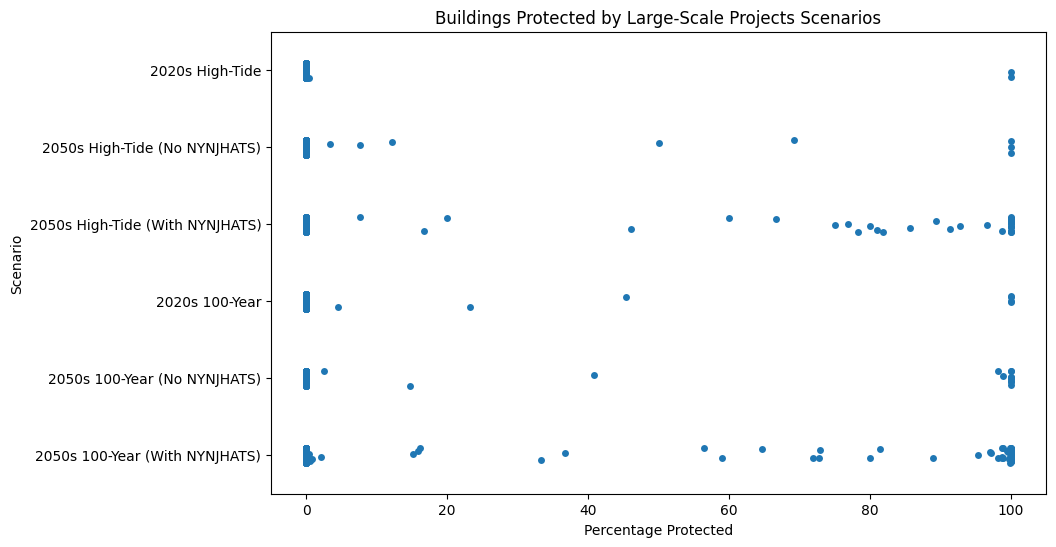

In [114]:
analysis_df["scenario_short"] = pd.Categorical(
    analysis_df["scenario_short"],
    categories=scenario_order,
    ordered=True
)

plt.figure(figsize=(10, 6))
sns.stripplot(data=analysis_df, x="percent_protected", y="scenario_short")
plt.title("Buildings Protected by Large-Scale Projects Scenarios")
plt.xlabel("Percentage Protected")
plt.ylabel("Scenario")
plt.show()

##Average percent across scenarios

/tmp/ipykernel_87104/4260563989.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chart1_df = analysis_df.groupby("scenario_short")["percent_protected"].mean().reindex(scenario_order)


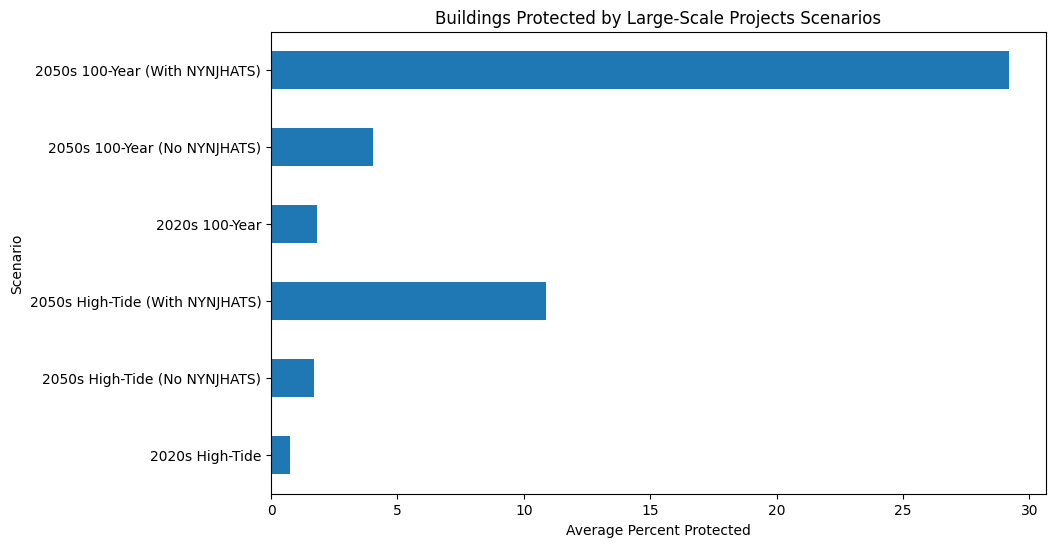

In [96]:
scenario_order = [
    "2020s High-Tide",
    "2050s High-Tide (No NYNJHATS)",
    "2050s High-Tide (With NYNJHATS)",
    "2020s 100-Year",
    "2050s 100-Year (No NYNJHATS)",
    "2050s 100-Year (With NYNJHATS)"
]
chart1_df = analysis_df.groupby("scenario_short")["percent_protected"].mean().reindex(scenario_order)

chart1_df.plot(kind="barh", figsize=(10, 6))
plt.title("Buildings Protected by Large-Scale Projects Scenarios")
plt.xlabel("Average Percent Protected")
plt.ylabel("Scenario")
plt.show()

##Which Neighborhoods Gain Protection of Buildings Protected by Large-Scale Projects With vs Without NYNJHATS


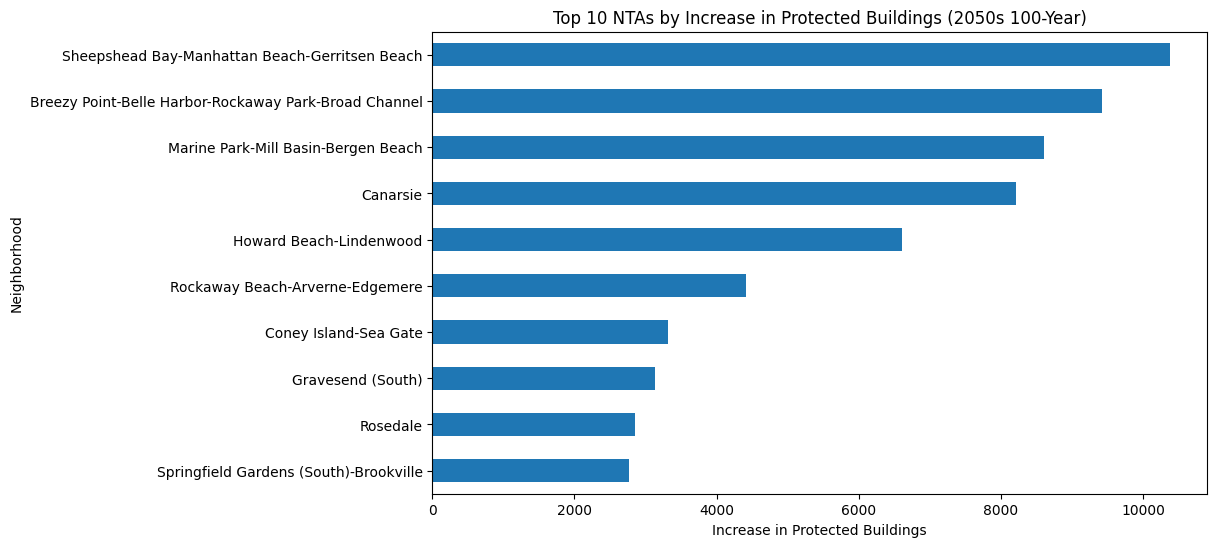

In [113]:
#create comparison
without_100_count = analysis_df[analysis_df["scenario_code"] == 7][["nta_name", "buildings_protected"]]
with_100_count = analysis_df[analysis_df["scenario_code"] == 8][["nta_name", "buildings_protected"]]

without_100_count = without_100_count.rename(columns={"buildings_protected": "without_nynjhats_count"})
with_100_count = with_100_count.rename(columns={"buildings_protected": "with_nynjhats_count"})

compare_100_count = with_100_count.merge(without_100_count, on="nta_name")
compare_100_count["gain_count"] = (
    compare_100_count["with_nynjhats_count"] - compare_100_count["without_nynjhats_count"]
)

top_gain_100 = compare_100.sort_values("gain", ascending=False).head(20)
#plot comparison
top_gain_count = compare_100_count.sort_values("gain_count", ascending=False).head(10)

top_gain_count.plot(
    kind="barh",
    x="nta_name",
    y="gain_count",
    figsize=(10, 6),
    legend=False
)
plt.title("Top 10 NTAs by Increase in Protected Buildings (2050s 100-Year)")
plt.xlabel("Increase in Protected Buildings")
plt.ylabel("Neighborhood")
plt.gca().invert_yaxis()
plt.show()

In [112]:
#filters the dataframe to just one scenario,
#sorts the neighborhoods from highest to lowest percent_protected then buildings_protected
#returns the top neighborhoods

def get_top_ntas(dataframe, scenario_code, n):
    filtered_df = dataframe[dataframe["scenario_code"] == scenario_code]
    sorted_df = filtered_df.sort_values(
        by=["percent_protected", "buildings_protected"],
        ascending=[False, False]
    )
    return sorted_df[[
        "nta_name",
        "buildings_protected",
        "buildings_at_risk",
        "percent_protected"
    ]].head(n)

get_top_ntas(analysis_df, 8, 10)

,nta_name,buildings_protected,buildings_at_risk,percent_protected
1389,Breezy Point-Belle Harbor-Rockaway Park-Broad Channel,9423,9423,100.0
369,Canarsie,8213,8213,100.0
1251,Howard Beach-Lindenwood,6608,6608,100.0
1491,New Dorp-Midland Beach,5924,5924,100.0
1485,Grasmere-Arrochar-South Beach-Dongan Hills,2887,2887,100.0
1365,Rosedale,2853,2853,100.0
1359,Springfield Gardens (South)-Brookville,2763,2763,100.0
357,Flatlands,2190,2190,100.0
303,Madison,2092,2092,100.0
297,Gravesend (East)-Homecrest,1814,1814,100.0
